In [97]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns 

In [98]:
df= pd.read_csv('../diabetes_dataset/diabetes.csv')

In [99]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
542,10,90,85,32,0,34.9,0.825,56,1
324,2,112,75,32,0,35.7,0.148,21,0
58,0,146,82,0,0,40.5,1.781,44,0
479,4,132,86,31,0,28.0,0.419,63,0
684,5,136,82,0,0,0.0,0.640,69,0


In [100]:
df=df.iloc[:,6:]

In [101]:
# df=df.iloc[:,1:]
# df=df.iloc[:,:5]

In [102]:
df.sample(5)

,DiabetesPedigreeFunction,Age,Outcome
75,0.140,22,0
732,0.646,24,1
179,0.956,37,1
727,0.433,22,0
326,0.692,30,1


Train test split

In [103]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1),
                                                            df['Outcome'],
                                                               test_size=0.3,
                                                               random_state=0)

In [104]:
x_train.shape, x_test.shape

((537, 2), (231, 2))

Standard Scaler

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit the scalar to the train set, it will learn the parameters
scaler.fit(x_train)

#transform train and test sets  
x_train_scaled= scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [106]:
scaler.mean_

array([ 0.4713203 , 33.67039106])

In [107]:
x_train

,DiabetesPedigreeFunction,Age
580,0.371,21
418,0.624,27
764,0.340,27
363,0.520,67
757,0.258,52
...,...,...
763,0.171,63
192,0.383,36
629,0.148,21
559,0.300,35


In [108]:
x_train_scaled

array([[-0.3002719 , -1.05654479],
       [ 0.45699051, -0.55622332],
       [-0.39305899, -0.55622332],
       ...,
       [-0.96774035, -1.05654479],
       [-0.51278428,  0.11087198],
       [ 0.50488062,  2.94602702]], shape=(537, 2))

In [109]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [110]:
x_train_scaled

,DiabetesPedigreeFunction,Age
0,-0.300272,-1.056545
1,0.456991,-0.556223
2,-0.393059,-0.556223
3,0.145705,2.779253
4,-0.638496,1.528450
...,...,...
532,-0.898898,2.445706
533,-0.264354,0.194259
534,-0.967740,-1.056545
535,-0.512784,0.110872


In [111]:
np.round(x_train.describe(),1)

,DiabetesPedigreeFunction,Age
count,537.0,537.0
mean,0.5,33.7
std,0.3,12.0
min,0.1,21.0
25%,0.2,24.0
50%,0.4,29.0
75%,0.6,41.0
max,2.4,81.0


In [112]:
np.round(x_train_scaled.describe(),1)

,DiabetesPedigreeFunction,Age
count,537.0,537.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.2,-1.1
25%,-0.7,-0.8
50%,-0.3,-0.4
75%,0.4,0.6
max,5.8,3.9


Effect of Scaling

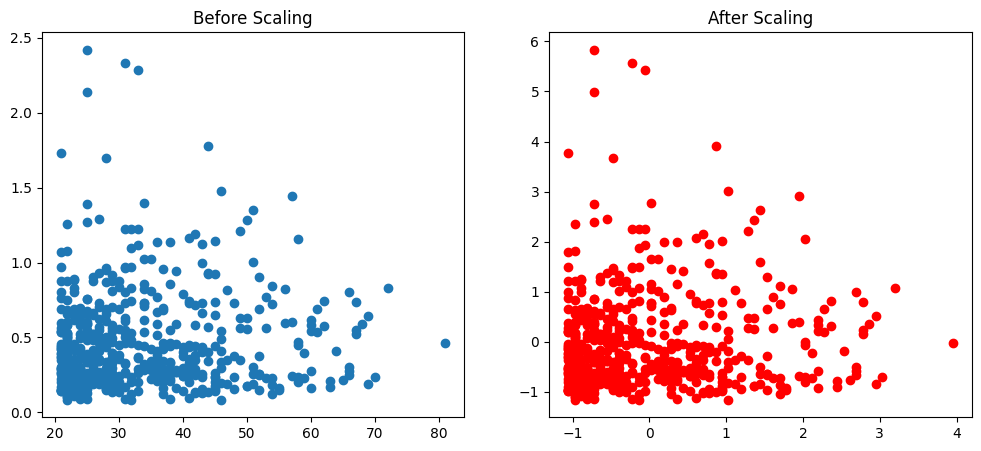

In [113]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['DiabetesPedigreeFunction'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['DiabetesPedigreeFunction'],color='red')
ax2.set_title("After Scaling")
plt.show()

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/

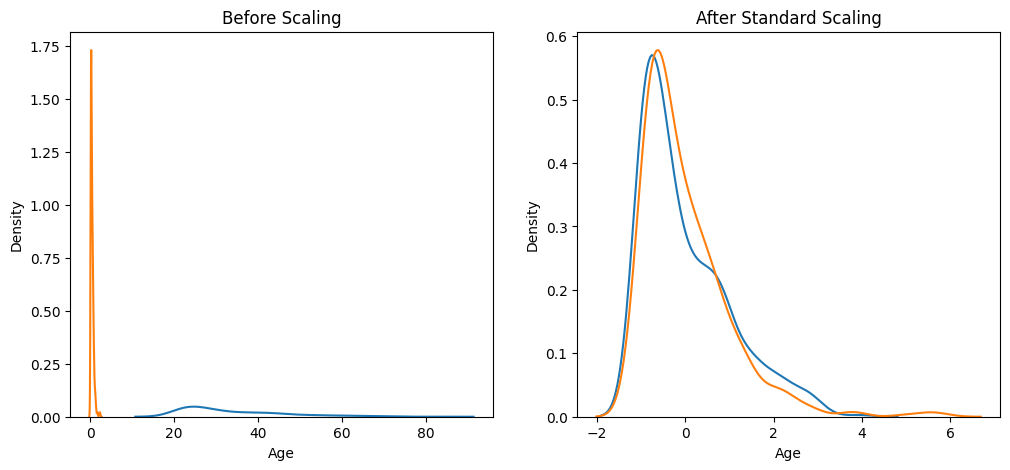

In [114]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['DiabetesPedigreeFunction'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['DiabetesPedigreeFunction'], ax=ax2)
plt.show()

Comparison of Distributions

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


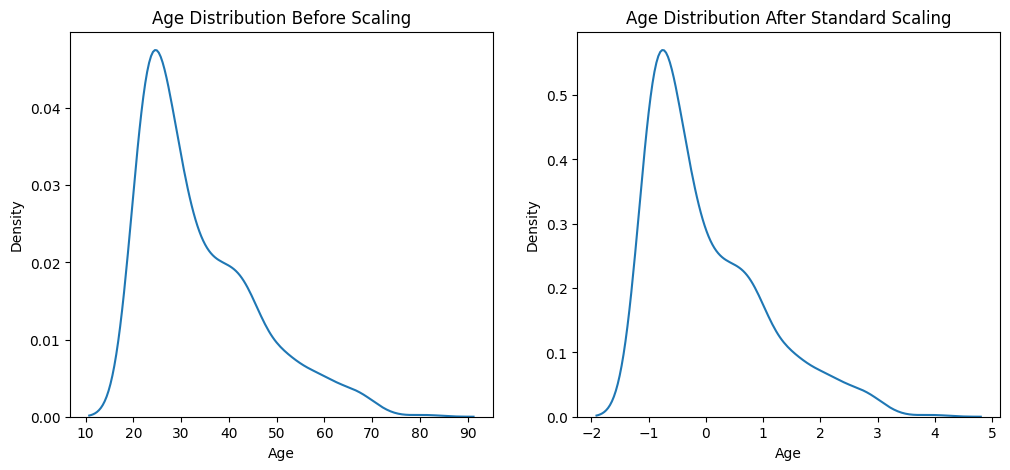

In [115]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()

/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/shukrina/Documents/vertex/vertex_projects/diabetes_detection/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


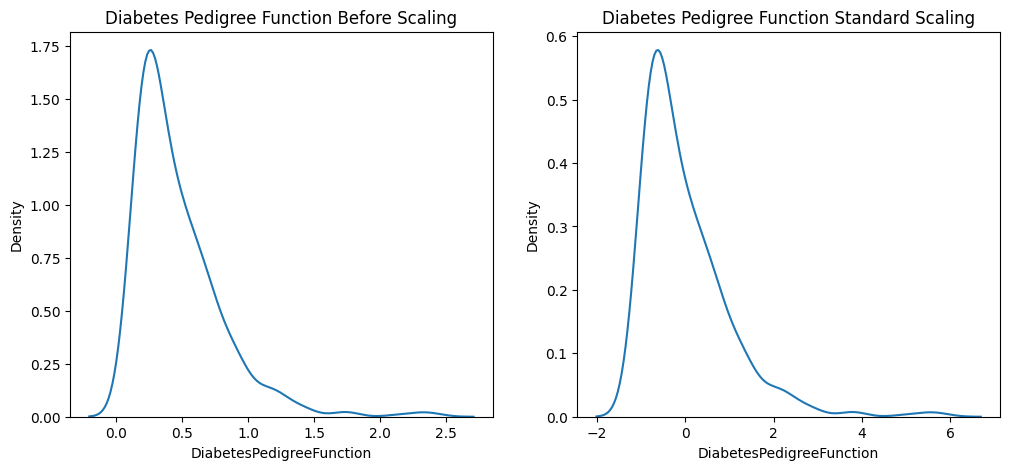

In [116]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Diabetes Pedigree Function Before Scaling')
sns.kdeplot(x_train['DiabetesPedigreeFunction'], ax=ax1)

# after scaling
ax2.set_title('Diabetes Pedigree Function Standard Scaling')
sns.kdeplot(x_train_scaled['DiabetesPedigreeFunction'], ax=ax2)
plt.show()

Why Scaling is important?

In [117]:
from sklearn.linear_model import LogisticRegression

In [118]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [119]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [120]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [121]:
from sklearn.metrics import accuracy_score

In [122]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.670995670995671
Scaled 0.670995670995671


In [123]:
from sklearn.tree import DecisionTreeClassifier

In [124]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [125]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [126]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [127]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.6103896103896104
Scaled 0.5930735930735931


In [128]:
df.describe()

,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000
mean,0.471876,33.240885,0.348958
std,0.331329,11.760232,0.476951
min,0.078000,21.000000,0.000000
25%,0.243750,24.000000,0.000000
50%,0.372500,29.000000,0.000000
75%,0.626250,41.000000,1.000000
max,2.420000,81.000000,1.000000


Effect of Outlier

In [129]:
new_rows = pd.DataFrame({
    'Age':[30,21,25],
    'DiabetesPedigreeFunction':[0.300,0.388,0.638],
    'Outcome':[0,1,1]
})

df = pd.concat([df, new_rows], ignore_index=True)  

#append is depreciated
#df = df.append(pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]}),ignore_index=True)


In [130]:
df

,DiabetesPedigreeFunction,Age,Outcome
0,0.627,50,1
1,0.351,31,0
2,0.672,32,1
3,0.167,21,0
4,2.288,33,1
...,...,...,...
766,0.349,47,1
767,0.315,23,0
768,0.300,30,0
769,0.388,21,1


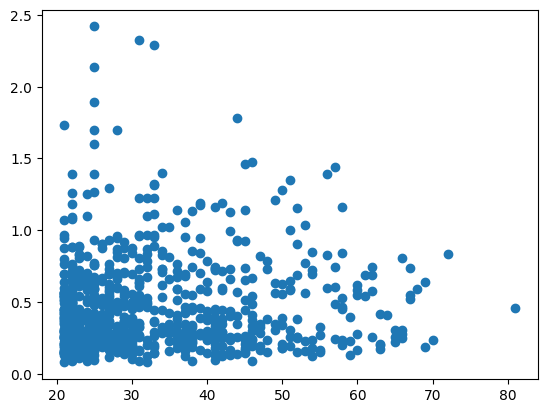

In [131]:
plt.scatter(df['Age'], df['DiabetesPedigreeFunction'])

In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1),
                                                    df['Outcome'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((539, 2), (232, 2))

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

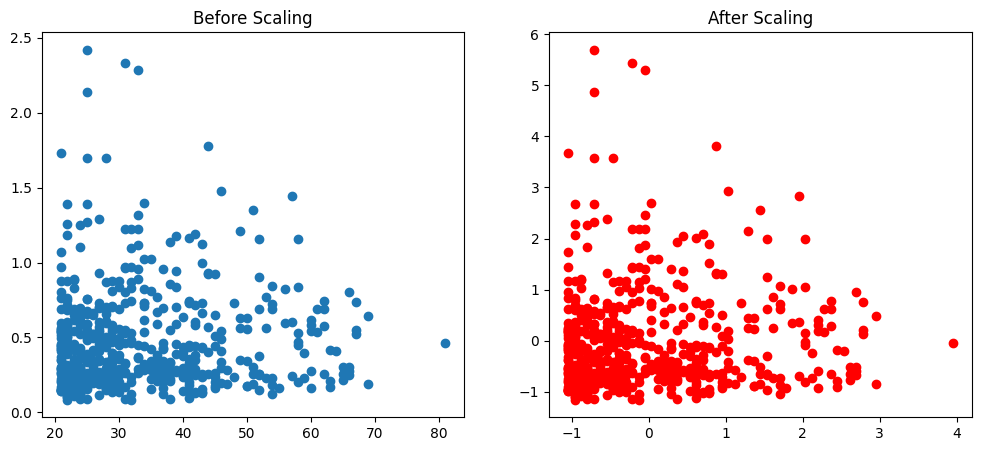

In [137]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['DiabetesPedigreeFunction'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['DiabetesPedigreeFunction'],color='red')
ax2.set_title("After Scaling")
plt.show()